Lab 4 - homework

In [44]:
import os
import gzip
from pathlib import Path
from itertools import islice, batched

import joblib
import torch
from PIL import Image
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import sqlalchemy as sa
from sqlalchemy import URL
from sqlalchemy.orm import DeclarativeBase, Mapped, mapped_column, Session
from sentence_transformers import SentenceTransformer
from pgvector.sqlalchemy import Vector

In [ ]:
# Paths
ROOT = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
META_CSV_GZ = ROOT / "images" / "metadata" / "images.csv.gz"
IMAGES_ROOT = ROOT / "images" / "small"

# Database connection parameters
PG_HOST = os.environ.get("PG_HOST", "localhost")
PG_PORT = int(os.environ.get("PG_PORT", "5432"))
PG_DB = os.environ.get("PG_DB", "similarity_search_service_db")
PG_USER = os.environ.get("PG_USER", "postgres")
PG_PASS = os.environ.get("PG_PASS", "password")

# Can be adjusted if needed
MIN_SIZE = int(os.environ.get("ABO_MIN_SIZE", "100"))
MAX_IMAGES = int(os.environ.get("MAX_IMAGES", "500"))
BATCH_SIZE = int(os.environ.get("BATCH_SIZE", str(joblib.cpu_count(only_physical_cores=True) or 4)))

# Torch device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

Dataset preparation

In [46]:
# Quick peek at header and first rows
with gzip.open(META_CSV_GZ, "rt", encoding="utf-8") as f:
    for line in islice(f, 5):
        print(line.strip())

image_id,height,width,path
010-mllS7JL,106,106,14/14fe8812.jpg
01dkn0Gyx0L,122,122,da/daab0cad.jpg
01sUPg0387L,111,111,d2/d2daaae9.jpg
1168jc-5r1L,186,186,3a/3a4e88e6.jpg


In [47]:
# Extract valid absolute image paths with size filter
def extract_image_paths(meta_csv_gz: Path, images_root: Path, min_size: int) -> list[Path]:
    rows = []
    with gzip.open(meta_csv_gz, "rt", encoding="utf-8") as f:
        header = f.readline().strip().split(",")
        # Expect: image_id,height,width,path
        idx_height = header.index("height")
        idx_width = header.index("width")
        idx_path = header.index("path")
        for line in f:
            parts = line.rstrip("\n").split(",")
            try:
                h = int(parts[idx_height])
                w = int(parts[idx_width])
            except Exception:
                continue
            if h >= min_size and w >= min_size:
                rel = parts[idx_path]
                p = images_root / rel
                if p.exists():
                    rows.append(p)
    return rows

image_paths = extract_image_paths(META_CSV_GZ, IMAGES_ROOT, MIN_SIZE)
print(f"Found {len(image_paths)} images with >= {MIN_SIZE}px.")

Found 397702 images with >= 100px.


Database setup

In [48]:
pg_url = URL.create(
    drivername="postgresql+psycopg",
    username=PG_USER,
    password=PG_PASS,
    host=PG_HOST,
    port=PG_PORT,
    database=PG_DB,
)
engine = sa.create_engine(pg_url, echo=False, pool_pre_ping=True)

class Base(DeclarativeBase):
    pass

class Img(Base):
    __tablename__ = "images"
    __table_args__ = {"extend_existing": True}

    VECTOR_LENGTH: int = 512  # clip-ViT-B-32 embedding size

    id: Mapped[int] = mapped_column(primary_key=True, autoincrement=True)
    image_path: Mapped[str] = mapped_column(sa.Text, nullable=False, unique=True)
    embedding: Mapped[list[float]] = mapped_column(Vector(dim=VECTOR_LENGTH), nullable=False)

# Create table
Base.metadata.create_all(engine)

Image vectorization and insertion

In [49]:
model = SentenceTransformer("clip-ViT-B-32", device=DEVICE)

def insert_images(engine, images: list[Img]):
    # bulk save for efficiency
    with Session(engine) as session:
        session.bulk_save_objects(images, return_defaults=False)
        session.commit()


def vectorize_images(engine, model: SentenceTransformer, image_paths: list[Path]):
    to_process = image_paths[:MAX_IMAGES]
    with tqdm(total=len(to_process)) as pbar:
        for paths_batch in batched(to_process, BATCH_SIZE):
            paths_batch = list(paths_batch)
            images = [Image.open(p).convert("RGB") for p in paths_batch]
            # Compute embeddings using encode on images; normalize for cosine
            emb = model.encode(images, batch_size=len(images), convert_to_numpy=True, normalize_embeddings=True) # type: ignore
            # Create ORM objects
            objs = [Img(image_path=str(p), embedding=emb[i].tolist()) for i, p in enumerate(paths_batch)]
            # Insert batch
            insert_images(engine, objs)
            # Update progress
            pbar.update(len(objs))

# Run vectorization 
vectorize_images(engine, model, image_paths)

  0%|          | 0/500 [00:00<?, ?it/s]

Search and results display

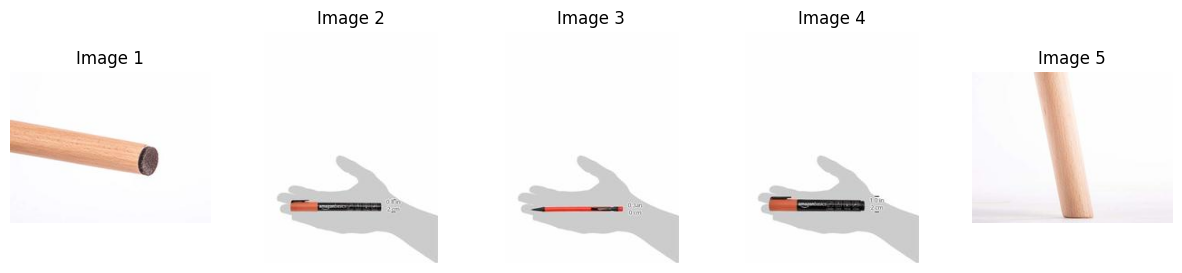

In [50]:
class ImageSearch:
    def __init__(self, engine, model: SentenceTransformer):
        self.engine = engine
        self.model = model

    def __call__(self, image_description: str, k: int = 5):
        found = self.find_similar_images(image_description, k)
        self.display_images([row[0] for row in found], k)
        return found

    def find_similar_images(self, image_description: str, k: int = 5):
        # Compute text embedding (normalize for cosine)
        emb = self.model.encode([image_description], convert_to_numpy=True, normalize_embeddings=True)[0]
        # Build query by inlining the vector as a literal (easier for demo/ad-hoc use)
        qvec_literal = "[" + ",".join(f"{float(x):.6f}" for x in emb.tolist()) + "]"
        sql = (
            "SELECT image_path, embedding <=> '" + qvec_literal + "'::vector AS distance "
            "FROM images "
            "ORDER BY embedding <=> '" + qvec_literal + "'::vector "
            f"LIMIT {int(k)}"
        )
        with self.engine.connect() as conn:
            result = conn.execute(sa.text(sql)).fetchall()
        return result

    def display_images(self, images: list[str], k: int):
        _, axes = plt.subplots(1, k, figsize=(3 * k, 3))
        for i, img_path in enumerate(images):
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].axis("off")
            axes[i].set_title(f"Image {i+1}")
        plt.show()

search = ImageSearch(engine, model)
res = search("pencil", k=5)